# RL Agent Comparison: Real PEMS / CityFlow Benchmark

This notebook compares four reinforcement learning agents for traffic signal control on real traffic demand generated from the PEMS04 dataset.

1. **Tabular Q-Learning** — Classic value-based method for small state spaces
2. **DQN** — Deep Q-Network with replay buffer and target network
3. **Double DQN** — Reduces Q-value overestimation using separate action selection
4. **Dueling DQN** — Splits network into value and advantage streams

**Flow:**
1. Load and convert PEMS04 demand data
2. Build CityFlow split configs
3. Train each agent on real traffic demand
4. Evaluate trained agents on train/val/test splits
5. Compare rewards, queues, throughput, and travel time

## Section 1: Imports and Setup

In [1]:
from __future__ import annotations

import copy
import json
import os
import sys
import time
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, JSON, Markdown, display

def _find_repo_root(start: Path) -> Path:
    """Find the repository root by looking for pyproject.toml."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError(f"Could not locate repo root from {start}")

REPO_ROOT = _find_repo_root(Path.cwd()).resolve()
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from traffic_rl.config import AppConfig, load_config
from traffic_rl.evaluation import run_evaluation
from traffic_rl.pems.pipeline import build_cityflow_demands, load_pems_demand_config
from traffic_rl.training import run_training

print(f"Repository root: {REPO_ROOT}")
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Repository root: /home/hd/projects/ML_project/traffic-rl
Python version: 3.10.20
NumPy version: 2.2.6
Pandas version: 2.3.3


/home/hd/projects/ML_project/traffic-rl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 2: Agent Comparison Matrix

Below is a summary of the four agents and their key characteristics.

In [2]:
# Agent comparison data
agent_comparison = {
    "Tabular Q-Learning": {
        "Type": "Value-based, Tabular",
        "State Space": "Small discrete",
        "Network": "None (lookup table)",
        "Complexity": "Very Low",
        "Convergence": "Guaranteed (tabular)",
        "Best For": "Baseline, small problems",
        "Key Innovation": "N/A"
    },
    "DQN": {
        "Type": "Value-based, Deep",
        "State Space": "Large continuous",
        "Network": "2-layer MLP",
        "Complexity": "Medium",
        "Convergence": "Replay buffer + target net",
        "Best For": "Quick deep RL baseline",
        "Key Innovation": "Experience replay, target network"
    },
    "Double DQN": {
        "Type": "Value-based, Deep",
        "State Space": "Large continuous",
        "Network": "2-layer MLP",
        "Complexity": "Medium",
        "Convergence": "Decoupled action selection",
        "Best For": "Production (stable learning)",
        "Key Innovation": "Online net → actions, target net → evaluation"
    },
    "Dueling DQN": {
        "Type": "Value-based, Deep",
        "State Space": "Large continuous",
        "Network": "Dueling (V + A streams)",
        "Complexity": "Medium-High",
        "Convergence": "Separate learning paths",
        "Best For": "Complex state spaces",
        "Key Innovation": "Q(s,a) = V(s) + A(s,a) - mean(A)"
    }
}

# Convert to DataFrame for display
comparison_df = pd.DataFrame(agent_comparison).T
print(comparison_df.to_string())
print()
display(HTML(comparison_df.to_html(classes='table table-striped table-bordered')))

                                    Type       State Space                  Network   Complexity                 Convergence                      Best For                                 Key Innovation
Tabular Q-Learning  Value-based, Tabular    Small discrete      None (lookup table)     Very Low        Guaranteed (tabular)      Baseline, small problems                                            N/A
DQN                    Value-based, Deep  Large continuous              2-layer MLP       Medium  Replay buffer + target net        Quick deep RL baseline              Experience replay, target network
Double DQN             Value-based, Deep  Large continuous              2-layer MLP       Medium  Decoupled action selection  Production (stable learning)  Online net → actions, target net → evaluation
Dueling DQN            Value-based, Deep  Large continuous  Dueling (V + A streams)  Medium-High     Separate learning paths          Complex state spaces               Q(s,a) = V(s) + A(s,a) 

,Type,State Space,Network,Complexity,Convergence,Best For,Key Innovation
Tabular Q-Learning,"Value-based, Tabular",Small discrete,None (lookup table),Very Low,Guaranteed (tabular),"Baseline, small problems",N/A
DQN,"Value-based, Deep",Large continuous,2-layer MLP,Medium,Replay buffer + target net,Quick deep RL baseline,"Experience replay, target network"
Double DQN,"Value-based, Deep",Large continuous,2-layer MLP,Medium,Decoupled action selection,Production (stable learning),"Online net → actions, target net → evaluation"
Dueling DQN,"Value-based, Deep",Large continuous,Dueling (V + A streams),Medium-High,Separate learning paths,Complex state spaces,"Q(s,a) = V(s) + A(s,a) - mean(A)"


## Section 3: Configuration and Real-Data Setup

Define hyperparameters, input paths, and the real-data benchmark settings.

## Section 3b: Inspect PEMS Data

Load the PEMS04 tensor and validate the source data before generating CityFlow demand files.

In [3]:
# Load and inspect the PEMS04 source tensor used to generate CityFlow demand files.
PEMS_CONFIG_PATH = REPO_ROOT / "configs" / "pems04_to_cityflow.example.yaml"
CITYFLOW_BASE_CONFIG_PATH = REPO_ROOT / "configs" / "cityflow.quick.yaml"

pems_cfg = load_pems_demand_config(PEMS_CONFIG_PATH)
pems_npz = np.load(pems_cfg.pems_npz_path)
pems_tensor = pems_npz["data"]

print(f"✓ PEMS config loaded: {PEMS_CONFIG_PATH}")
print(f"  Tensor path: {pems_cfg.pems_npz_path}")
print(f"  Output dir: {pems_cfg.output_dir}")
print(f"  Shape: {pems_tensor.shape} (timesteps, sensors, features)")
print(f"  Data type: {pems_tensor.dtype}")
print(f"  Min / mean / max: {float(pems_tensor.min()):.3f} / {float(pems_tensor.mean()):.3f} / {float(pems_tensor.max()):.3f}")
print(f"  Sensors used for conversion: {len(pems_cfg.sensor_indices)}")
print(f"  Flow feature index: {pems_cfg.flow_feature_index}")

✓ PEMS config loaded: /home/hd/projects/ML_project/traffic-rl/configs/pems04_to_cityflow.example.yaml
  Tensor path: /home/hd/projects/ML_project/traffic-rl/Pems_Dataset/PEMS04/PEMS04.npz
  Output dir: /home/hd/projects/ML_project/traffic-rl/outputs/pems04
  Shape: (16992, 307, 3) (timesteps, sensors, features)
  Data type: float64
  Min / mean / max: 0.000 / 91.741 / 919.000
  Sensors used for conversion: 4
  Flow feature index: 0


In [4]:
QUICK_MODE = False
if QUICK_MODE:
    TRAIN_EPISODES = 3
    TRAIN_MAX_STEPS = 40
    EVAL_EPISODES = 5
    EVAL_SEEDS = 3
else:
    TRAIN_EPISODES = 30
    TRAIN_MAX_STEPS = 120
    EVAL_EPISODES = 10
    EVAL_SEEDS = 5

# Shared training hyperparameters mirrored from the comparison CLI.
SHARED_HYPERPARAMS = {
    "gamma": 0.99,
    "learning_rate": 0.001,
    "epsilon_start": 1.0,
    "epsilon_end": 0.01,
    "epsilon_decay": 0.995,
    "hidden_dim": 64,
    "batch_size": 32,
    "replay_capacity": 10000,
    "learning_starts": 500,
    "target_update_interval": 500,
    "train_frequency": 4,
    "seed": 42,
}

# Benchmark settings for the real-data comparison.
BENCHMARK_CONFIG = {
    "train_episodes": TRAIN_EPISODES,
    "train_max_steps": TRAIN_MAX_STEPS,
    "eval_episodes": EVAL_EPISODES,
    "eval_seeds": EVAL_SEEDS,
}

display(Markdown("### Hyperparameters"))
display(JSON(SHARED_HYPERPARAMS, expanded=False))

print()
display(Markdown("### Benchmark Settings"))
display(JSON(BENCHMARK_CONFIG, expanded=False))

### Hyperparameters

<IPython.core.display.JSON object>

### Benchmark Settings

<IPython.core.display.JSON object>

## Section 4: Real PEMS Environment and Agent Evaluation

Use the PEMS04 dataset to benchmark the agents on real traffic flow data.
The synthetic fallback has been removed so the notebook now measures behavior only on the real dataset.

In [5]:
def _resolve_from_yaml(config_path: Path, value: str) -> str:
    path = Path(value)
    if path.is_absolute():
        return str(path)
    return str((config_path.parent / path).resolve())


def _resolve_engine_dir(base_engine_path: Path, engine_dir_value: str, repo_root: Path) -> Path:
    engine_dir_path = Path(engine_dir_value)
    if not engine_dir_path.is_absolute():
        engine_dir_path = (base_engine_path.parent / engine_dir_path).resolve()
    if not engine_dir_path.exists():
        fallback = (repo_root / "cityflow_data").resolve()
        if fallback.exists():
            return fallback
    return engine_dir_path.resolve()


def _to_engine_relative(engine_dir: Path, flow_path: Path) -> str:
    return os.path.relpath(flow_path.resolve(), engine_dir.resolve())


def _to_cityflow_dir_string(engine_dir: Path) -> str:
    value = str(engine_dir.resolve())
    if not value.endswith(os.sep):
        value += os.sep
    return value


def create_agent_config(agent_type: str, output_dir: Path) -> AppConfig:
    """Create AppConfig for a specific agent type and output location."""
    cfg = AppConfig()
    cfg.training.agent_type = agent_type
    cfg.training.gamma = SHARED_HYPERPARAMS["gamma"]
    cfg.training.learning_rate = SHARED_HYPERPARAMS["learning_rate"]
    cfg.training.epsilon_start = SHARED_HYPERPARAMS["epsilon_start"]
    cfg.training.epsilon_end = SHARED_HYPERPARAMS["epsilon_end"]
    cfg.training.epsilon_decay = SHARED_HYPERPARAMS["epsilon_decay"]
    cfg.training.hidden_dim = SHARED_HYPERPARAMS["hidden_dim"]
    cfg.training.batch_size = SHARED_HYPERPARAMS["batch_size"]
    cfg.training.replay_capacity = SHARED_HYPERPARAMS["replay_capacity"]
    cfg.training.learning_starts = SHARED_HYPERPARAMS["learning_starts"]
    cfg.training.target_update_interval = SHARED_HYPERPARAMS["target_update_interval"]
    cfg.training.train_frequency = SHARED_HYPERPARAMS["train_frequency"]
    cfg.seed = SHARED_HYPERPARAMS["seed"]
    cfg.output_dir = str(output_dir)
    return cfg

## Section 5: Train and Evaluate Agents on Real Data

Train each agent on the generated CityFlow demand and evaluate the resulting checkpoints on the real splits.

In [6]:
prep_cfg = copy.deepcopy(pems_cfg)
if QUICK_MODE:
    if len(prep_cfg.sensor_indices) > 2:
        prep_cfg.sensor_indices = prep_cfg.sensor_indices[:2]
    prep_cfg.split.train_days = 1
    prep_cfg.split.val_days = 1
    prep_cfg.split.test_days = 1
    prep_cfg.arrival_process = "uniform"

prep_cfg.output_dir = str(REPO_ROOT / "outputs" / ("agent_comparison_quick" if QUICK_MODE else "agent_comparison"))
prep_outputs = build_cityflow_demands(prep_cfg)
prep_summary = json.loads(Path(prep_outputs.summary_file).read_text(encoding="utf-8"))

display(Markdown("### Demand Build Artifacts"))
print(f"train flow : {prep_outputs.train_flow_file}")
print(f"val flow   : {prep_outputs.val_flow_file}")
print(f"test flow  : {prep_outputs.test_flow_file}")
print(f"summary    : {prep_outputs.summary_file}")
display(JSON(prep_summary, expanded=True))

base_raw = yaml.safe_load(CITYFLOW_BASE_CONFIG_PATH.read_text(encoding="utf-8")) or {}
base_engine_path = Path(_resolve_from_yaml(CITYFLOW_BASE_CONFIG_PATH, str(base_raw["env"]["cityflow_config_path"])))
engine_raw = json.loads(base_engine_path.read_text(encoding="utf-8"))

notebook_cfg_dir = REPO_ROOT / "outputs" / "notebook_run"
notebook_cfg_dir.mkdir(parents=True, exist_ok=True)

split_to_flow = {
    "train": Path(prep_outputs.train_flow_file),
    "val": Path(prep_outputs.val_flow_file),
    "test": Path(prep_outputs.test_flow_file),
}

split_cfg_paths: dict[str, str] = {}
for split_name, flow_path in split_to_flow.items():
    split_engine = copy.deepcopy(engine_raw)
    resolved_engine_dir = _resolve_engine_dir(base_engine_path, str(split_engine.get("dir", ".")), REPO_ROOT)
    split_engine["dir"] = _to_cityflow_dir_string(resolved_engine_dir)
    split_engine["flowFile"] = _to_engine_relative(resolved_engine_dir, flow_path)

    engine_out = notebook_cfg_dir / f"cityflow_engine_{split_name}.json"
    engine_out.write_text(json.dumps(split_engine, indent=2), encoding="utf-8")

    split_cfg_raw = copy.deepcopy(base_raw)
    split_cfg_raw["env"]["cityflow_config_path"] = str(engine_out)
    split_cfg_path = notebook_cfg_dir / f"cityflow_{split_name}.yaml"
    split_cfg_path.write_text(yaml.safe_dump(split_cfg_raw, sort_keys=False), encoding="utf-8")
    split_cfg_paths[split_name] = str(split_cfg_path)

display(JSON({
    "split_mode": "cityflow",
    "split_config_paths": split_cfg_paths,
}, expanded=True))

Building test split: 100%|██████████| 288/288 [00:00<00:00, 622.48window/s] 


### Demand Build Artifacts

train flow : /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/flow_train.json
val flow   : /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/flow_val.json
test flow  : /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/flow_test.json
summary    : /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/summary.json


<IPython.core.display.JSON object>

<IPython.core.display.JSON object>

In [ ]:
def benchmark_agent(agent_type: str) -> dict:
    """Train and evaluate one agent on the real PEMS/CityFlow splits."""
    agent_output_dir = REPO_ROOT / "outputs" / "agent_comparison" / agent_type
    agent_output_dir.mkdir(parents=True, exist_ok=True)

    train_cfg = load_config(split_cfg_paths["train"])
    train_cfg.training.agent_type = agent_type
    train_cfg.training.episodes = TRAIN_EPISODES
    train_cfg.training.max_steps = TRAIN_MAX_STEPS
    train_cfg.output_dir = str(agent_output_dir)

    train_start = time.time()
    train_summary = run_training(train_cfg)
    train_wall_time = time.time() - train_start

    evaluation: dict[str, dict] = {}
    for split_name in ("train", "val", "test"):
        seed_rows: list[dict] = []
        base_eval_cfg = load_config(split_cfg_paths[split_name])
        base_eval_cfg.training.agent_type = agent_type
        base_eval_cfg.training.max_steps = TRAIN_MAX_STEPS
        base_eval_cfg.output_dir = str(agent_output_dir)

        for seed_offset in range(EVAL_SEEDS):
            eval_cfg = copy.deepcopy(base_eval_cfg)
            eval_cfg.seed = int(base_eval_cfg.seed + seed_offset)

            eval_summary = run_evaluation(
                eval_cfg,
                episodes=EVAL_EPISODES,
                checkpoint_path=None,
                replay_file=None,
                load_checkpoint=True,
                show_progress=False,
            )

            seed_rows.append({
                "seed": int(eval_cfg.seed),
                "episodes": int(eval_summary.episodes),
                "average_reward": float(eval_summary.average_reward),
                "average_queue": float(eval_summary.average_queue),
                "average_throughput": float(eval_summary.average_throughput),
                "average_travel_time": float(eval_summary.average_travel_time),
                "episode_rewards": [float(value) for value in eval_summary.episode_rewards],
            })

        evaluation[split_name] = {
            "num_seeds": int(EVAL_SEEDS),
            "by_seed": seed_rows,
            "average_reward": float(np.mean([row["average_reward"] for row in seed_rows]) if seed_rows else 0.0),
            "average_queue": float(np.mean([row["average_queue"] for row in seed_rows]) if seed_rows else 0.0),
            "average_throughput": float(np.mean([row["average_throughput"] for row in seed_rows]) if seed_rows else 0.0),
            "average_travel_time": float(np.mean([row["average_travel_time"] for row in seed_rows]) if seed_rows else 0.0),
            "episode_rewards": [reward for row in seed_rows for reward in row["episode_rewards"]],
        }

    return {
        "agent_type": agent_type,
        "train_wall_time_seconds": float(train_wall_time),
        "training": asdict(train_summary),
        "evaluation": evaluation,
    }

agent_types = ["tabular_q", "dqn", "double_dqn", "dueling_dqn"]
benchmark_results = {}

print("Running benchmarks on PEMS04-derived CityFlow splits")
print(f"Agents: {', '.join(agent_types)}")
print(f"Train episodes: {TRAIN_EPISODES}, train max steps: {TRAIN_MAX_STEPS}")
print(f"Eval episodes: {EVAL_EPISODES}, eval seeds: {EVAL_SEEDS}")
print()

for agent_type in agent_types:
    print(f"Benchmarking {agent_type.upper():20s} ...", end=" ", flush=True)
    try:
        result = benchmark_agent(agent_type)
        benchmark_results[agent_type] = result
        test_result = result["evaluation"]["test"]
        print(f"✓ Test Reward: {test_result['average_reward']:7.3f}, Test Travel Time: {test_result['average_travel_time']:6.3f}s")
    except Exception as e:
        print(f"✗ Error: {e}")

print("\nBenchmark complete!")

Running benchmarks on PEMS04-derived CityFlow splits
Agents: tabular_q, dqn, double_dqn, dueling_dqn
Train episodes: 30, train max steps: 120
Eval episodes: 10, eval seeds: 5

Benchmarking TABULAR_Q            ... 

Training episodes:   3%|▎         | 1/30 [00:04<02:18,  4.77s/ep, avg=-2646.0, reward=-2646.0, trend=[############----]]

[train] ep 001/030 reward= -2646.0 avg= -2646.0 [############----]


Training episodes:   7%|▋         | 2/30 [00:09<02:14,  4.82s/ep, avg=-2340.0, reward=-2034.0, trend=[#############---]]

[train] ep 002/030 reward= -2034.0 avg= -2340.0 [#############---]


...

[train] ep 028/030 reward= -2596.0 avg= -3066.6 [#############---]


Training episodes:  97%|█████████▋| 29/30 [02:16<00:04,  4.99s/ep, avg=-3050.3, reward=-2596.0, trend=[#############---]]

[train] ep 029/030 reward= -2596.0 avg= -3050.3 [#############---]


Training episodes: 100%|██████████| 30/30 [02:21<00:00,  4.72s/ep, avg=-3035.2, reward=-2596.0, trend=[#############---]]


[train] ep 030/030 reward= -2596.0 avg= -3035.2 [#############---]


## Section 6: Results Summary

Display benchmark results in a formatted table.

In [ ]:
# Create results DataFrame
results_data = []
for agent_type, result in benchmark_results.items():
    train_summary = result["training"]
    test_result = result["evaluation"]["test"]
    results_data.append({
        "Agent": agent_type.upper(),
        "Train Avg Reward": train_summary["average_reward"],
        "Test Avg Reward": test_result["average_reward"],
        "Test Avg Queue": test_result["average_queue"],
        "Test Avg Throughput": test_result["average_throughput"],
        "Test Avg Travel Time": test_result["average_travel_time"],
        "Train Time (s)": result["train_wall_time_seconds"],
    })

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values("Test Avg Reward", ascending=False)

print()
display(Markdown("### Benchmark Results (PEMS04 / CityFlow) — Sorted by Test Avg Reward"))
print(results_df.to_string(index=False))
print()
display(HTML(results_df.to_html(index=False, classes='table table-striped table-bordered')))

### Benchmark Results (PEMS04 / CityFlow) — Sorted by Test Avg Reward

      Agent  Train Avg Reward  Test Avg Reward  Test Avg Queue  Test Avg Throughput  Test Avg Travel Time  Train Time (s)
        DQN      -6288.384230     -4041.747038        0.510938            50.375000             78.562624       40.296588
  TABULAR_Q      -8359.047422     -4056.305671        0.510938            50.375000             78.562624      145.050723
DUELING_DQN      -4670.080726     -4056.305671        0.510938            50.375000             78.562624       40.971066
 DOUBLE_DQN      -6583.137113     -7984.938120        2.306771            74.591667             97.489442       40.977347



Agent,Train Avg Reward,Test Avg Reward,Test Avg Queue,Test Avg Throughput,Test Avg Travel Time,Train Time (s)
DQN,-6288.384230,-4041.747038,0.510938,50.375000,78.562624,40.296588
TABULAR_Q,-8359.047422,-4056.305671,0.510938,50.375000,78.562624,145.050723
DUELING_DQN,-4670.080726,-4056.305671,0.510938,50.375000,78.562624,40.971066
DOUBLE_DQN,-6583.137113,-7984.938120,2.306771,74.591667,97.489442,40.977347


## Section 7: Performance Visualization

Plot episode rewards over time for each agent.

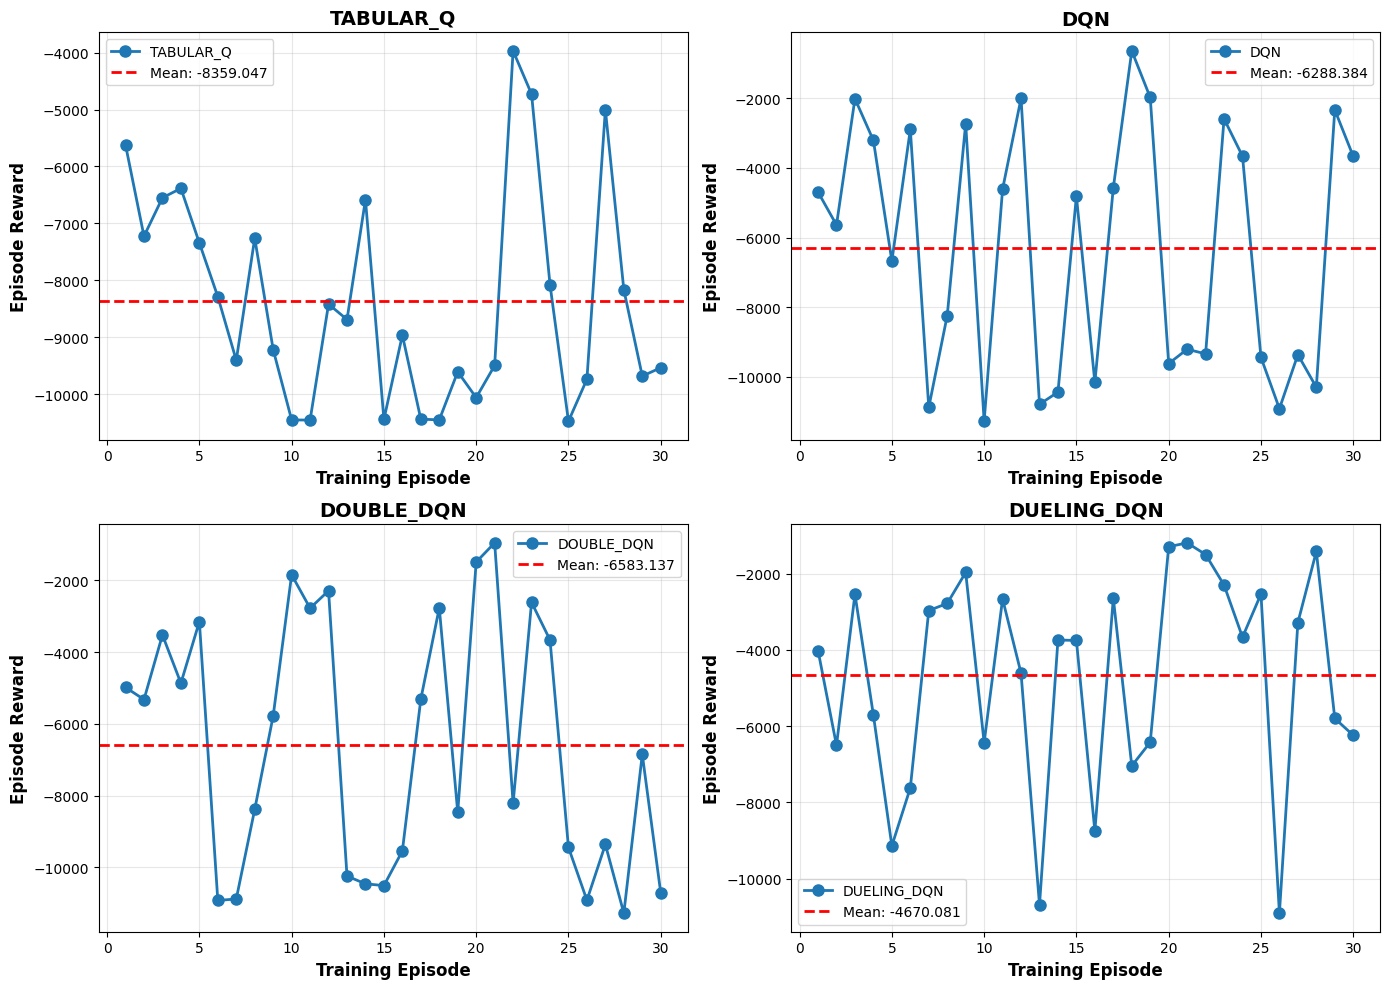

Saved: outputs/agent_comparison/episode_rewards.png


In [ ]:
import matplotlib.pyplot as plt

# Ensure output directory exists
output_dir = REPO_ROOT / 'outputs' / 'agent_comparison'
output_dir.mkdir(parents=True, exist_ok=True)

# Create subplots for each agent
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (agent_type, result) in enumerate(benchmark_results.items()):
    ax = axes[idx]
    episode_rewards = result["training"]["episode_rewards"]
    episodes = list(range(1, len(episode_rewards) + 1))

    ax.plot(episodes, episode_rewards, marker='o', linestyle='-', linewidth=2, markersize=8, label=agent_type.upper())
    ax.axhline(y=np.mean(episode_rewards), color='r', linestyle='--', linewidth=2, label=f'Mean: {np.mean(episode_rewards):.3f}')

    ax.set_xlabel('Training Episode', fontsize=12, fontweight='bold')
    ax.set_ylabel('Episode Reward', fontsize=12, fontweight='bold')
    ax.set_title(f'{agent_type.upper()}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(output_dir / 'episode_rewards.png', dpi=100, bbox_inches='tight')
plt.show()

print("Saved: outputs/agent_comparison/episode_rewards.png")

## Section 8: Comparative Analysis

Analyze performance metrics and provide recommendations.

In [ ]:
# Find best agents by different metrics
best_by_reward = max(benchmark_results.items(), key=lambda item: item[1]["evaluation"]["test"]["average_reward"] )
best_by_time = min(benchmark_results.items(), key=lambda item: item[1]["train_wall_time_seconds"])
best_by_queue = min(benchmark_results.items(), key=lambda item: item[1]["evaluation"]["test"]["average_queue"])
best_by_travel_time = min(benchmark_results.items(), key=lambda item: item[1]["evaluation"]["test"]["average_travel_time"] )

analysis = {
    "Best by Test Average Reward": {
        "Agent": best_by_reward[0].upper(),
        "Reward": f"{best_by_reward[1]['evaluation']['test']['average_reward']:.4f}",
        "Queue": f"{best_by_reward[1]['evaluation']['test']['average_queue']:.4f}",
        "Travel Time": f"{best_by_reward[1]['evaluation']['test']['average_travel_time']:.4f}",
    },
    "Fastest Training": {
        "Agent": best_by_time[0].upper(),
        "Train Time (s)": f"{best_by_time[1]['train_wall_time_seconds']:.4f}",
        "Test Reward": f"{best_by_time[1]['evaluation']['test']['average_reward']:.4f}",
    },
    "Lowest Test Queue": {
        "Agent": best_by_queue[0].upper(),
        "Queue": f"{best_by_queue[1]['evaluation']['test']['average_queue']:.4f}",
        "Test Reward": f"{best_by_queue[1]['evaluation']['test']['average_reward']:.4f}",
    },
    "Lowest Test Travel Time": {
        "Agent": best_by_travel_time[0].upper(),
        "Travel Time": f"{best_by_travel_time[1]['evaluation']['test']['average_travel_time']:.4f}",
        "Test Reward": f"{best_by_travel_time[1]['evaluation']['test']['average_reward']:.4f}",
    },
}

display(Markdown("### Performance Winners"))
for category, winner in analysis.items():
    display(Markdown(f"#### {category}"))
    display(JSON(winner))

### Performance Winners

#### Best by Test Average Reward

<IPython.core.display.JSON object>

#### Fastest Training

<IPython.core.display.JSON object>

#### Lowest Test Queue

<IPython.core.display.JSON object>

#### Lowest Test Travel Time

<IPython.core.display.JSON object>

## Section 9: Recommendations

Guidance for selecting an agent for different scenarios.

In [ ]:
recommendations = """
## When to Use Each Agent

### 1. Tabular Q-Learning
- ✓ Use if: State space is small and discretizable
- ✓ Use if: You need maximum interpretability and speed
- ✗ Avoid if: State space is continuous or very large
- **Example**: Simple grid worlds or traffic problems with few discrete lane/phase combinations

### 2. DQN
- ✓ Use if: You need a deep RL baseline for complex state spaces
- ✓ Use if: You want a balance between performance and simplicity
- ✗ Avoid if: You need maximum stability (Q-value overestimation is a known issue)
- **Example**: Real traffic signal control with continuous sensor readings

### 3. Double DQN (Recommended for Production)
- ✓ Use if: You need stable learning with less bias
- ✓ Use if: You're building a production system
- ✓ Use if: You want the best balance of performance and stability
- ✗ Avoid if: You need absolute maximum training speed (slightly slower than DQN)
- **Example**: Real-world traffic signal controllers requiring reliable performance

### 4. Dueling DQN
- ✓ Use if: State value and action advantages are clearly separable
- ✓ Use if: You have complex state spaces with high dimensionality
- ✗ Avoid if: You need maximum simplicity or speed
- ✗ Avoid if: Results show high variance (architectural overhead not beneficial)
- **Example**: Complex traffic networks with rich state information

## Quick Decision Tree

1. **Small discrete state space?** → Tabular Q-Learning
2. **First quick baseline?** → DQN
3. **Production/stable learning?** → Double DQN ⭐
4. **Complex state space?** → Dueling DQN
5. **Unsure?** → Start with Double DQN, benchmark others later
"""

display(Markdown(recommendations))


## When to Use Each Agent

### 1. Tabular Q-Learning
- ✓ Use if: State space is small and discretizable
- ✓ Use if: You need maximum interpretability and speed
- ✗ Avoid if: State space is continuous or very large
- **Example**: Simple grid worlds or traffic problems with few discrete lane/phase combinations

### 2. DQN
- ✓ Use if: You need a deep RL baseline for complex state spaces
- ✓ Use if: You want a balance between performance and simplicity
- ✗ Avoid if: You need maximum stability (Q-value overestimation is a known issue)
- **Example**: Real traffic signal control with continuous sensor readings

### 3. Double DQN (Recommended for Production)
- ✓ Use if: You need stable learning with less bias
- ✓ Use if: You're building a production system
- ✓ Use if: You want the best balance of performance and stability
- ✗ Avoid if: You need absolute maximum training speed (slightly slower than DQN)
- **Example**: Real-world traffic signal controllers requiring reliable performance

### 4. Dueling DQN
- ✓ Use if: State value and action advantages are clearly separable
- ✓ Use if: You have complex state spaces with high dimensionality
- ✗ Avoid if: You need maximum simplicity or speed
- ✗ Avoid if: Results show high variance (architectural overhead not beneficial)
- **Example**: Complex traffic networks with rich state information

## Quick Decision Tree

1. **Small discrete state space?** → Tabular Q-Learning
2. **First quick baseline?** → DQN
3. **Production/stable learning?** → Double DQN ⭐
4. **Complex state space?** → Dueling DQN
5. **Unsure?** → Start with Double DQN, benchmark others later


## Section 10: Save and Export Results

In [ ]:
# Ensure output directory exists
output_dir = REPO_ROOT / "outputs" / "agent_comparison"
output_dir.mkdir(parents=True, exist_ok=True)

# Save benchmark results to JSON
results_json_path = output_dir / "benchmark_results.json"
with open(results_json_path, "w") as f:
    json.dump(benchmark_results, f, indent=2)

print(f"✓ Saved benchmark results to: {results_json_path}")

# Save summary statistics
summary_stats = {
    "timestamp": pd.Timestamp.now().isoformat(),
    "data_source": "PEMS04 / CityFlow",
    "pems_info": {
        "timesteps": int(pems_tensor.shape[0]),
        "sensors": int(pems_tensor.shape[1]),
        "features": int(pems_tensor.shape[2]),
    },
    "benchmark_config": BENCHMARK_CONFIG,
    "hyperparameters": SHARED_HYPERPARAMS,
    "best_agents": {
        "by_reward": {"agent": best_by_reward[0], "value": best_by_reward[1]["evaluation"]["test"]["average_reward"]},
        "by_speed": {"agent": best_by_time[0], "value": best_by_time[1]["train_wall_time_seconds"]},
        "by_queue": {"agent": best_by_queue[0], "value": best_by_queue[1]["evaluation"]["test"]["average_queue"]},
        "by_travel_time": {"agent": best_by_travel_time[0], "value": best_by_travel_time[1]["evaluation"]["test"]["average_travel_time"]},
    },
    "results": benchmark_results,
}

summary_json_path = output_dir / "summary_stats.json"
with open(summary_json_path, "w") as f:
    json.dump(summary_stats, f, indent=2)

print(f"✓ Saved summary stats to: {summary_json_path}")
print()
print(f"Output directory: {output_dir}")
print(f"Data source: PEMS04 / CityFlow")
print(f"Files:")
for f in sorted(output_dir.glob("*.json")):
    print(f"  - {f.name}")
for f in sorted(output_dir.glob("*.png")):
    print(f"  - {f.name}")

✓ Saved benchmark results to: /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/benchmark_results.json
✓ Saved summary stats to: /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison/summary_stats.json

Output directory: /home/hd/projects/ML_project/traffic-rl/outputs/agent_comparison
Data source: PEMS04 / CityFlow
Files:
  - benchmark_results.json
  - flow_test.json
  - flow_train.json
  - flow_val.json
  - summary.json
  - summary_stats.json
  - episode_rewards.png
